In [1]:

import multiprocessing

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy.optimize import curve_fit
from scipy.stats import norm
from matplotlib.ticker import MultipleLocator


# FUNCTIONS

In [2]:

def add_peak(ax, x, text, y_text, y_line_top=60):
    """
    ax       : axis
    x        : posizione del picco (keV)
    text     : label da scrivere
    y_text   : posizione testo
    y_line_top : altezza linea verticale
    """

    # linea verticale tratteggiata
    ax.vlines(
        x,
        0,
        y_line_top,
        ls='--',
        color='black',
        alpha=0.75
    )

    # annotazione (ruotata come nel tuo esempio)
    ax.annotate(
        text,
        xy=(x - 2, y_text),
        rotation=90,
        fontsize=11
    )

In [3]:


# ============================================================
# BUILD TOTAL DATASET
# ============================================================
def build_total_spectrum(files_config, bins):
    all_histograms = []
    total_time = 0

    for key, cfg in files_config.items():
        E, spectrum = load_spectrum(
            cfg["path"],
            cfg["calibration"],
            ENERGY_RANGE,
        )

        E_centers, counts = make_histogram(E, spectrum, bins)

        all_histograms.append(counts)
        total_time += cfg["time"]

    total_counts = np.sum(all_histograms, axis=0)

    return E_centers, total_counts, total_time

In [4]:

# ============================================================
# GAUSSIAN MODEL
# ============================================================
def gaussian_plus_bg(E, mu, sigma, area, m, background, ):


    gaussian = (
        area
        / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((E - mu) / sigma) ** 2)
    )

    return gaussian + background + m*E


In [5]:
# ============================================================
# HISTOGRAMMING
# ============================================================
def make_histogram(E, spectrum, bins):
    counts, edges = np.histogram(E, bins=bins, weights=spectrum)
    centers = 0.5 * (edges[1:] + edges[:-1])

    return centers, counts



In [6]:

# ============================================================
# DATA LOADING
# ============================================================
def load_spectrum(file_path, calibration, energy_range=(0, 3000)):
    """
    Load raw spectrum and convert channels to energy.
    """

    data = pd.read_csv(file_path, header=None)
    spectrum = data[0].to_numpy(dtype=np.float64)

    channels = np.arange(len(spectrum))

    E = (
        channels * calibration["a"]
        + calibration["b"]
        + calibration["c"] * channels**2
    )

    mask = (E >= energy_range[0]) & (E <= energy_range[1])

    return E[mask], spectrum[mask]

In [7]:
# ============================================================
# ENERGY RESOLUTION
# ============================================================
def sigma_fun(E):
    """
    Detector energy resolution model.
    Returns sigma in keV.
    """
    A = 3.68436e1
    B = 1.72714e4

    return (E * np.sqrt(A / E + B / E**2)) / 2.355 / 100
    


# Plot setup

In [8]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

# DATI

In [9]:
# ============================================================
# CONFIGURATION
# ============================================================
FILES = {
    "50d": {
        "path": "csv-files/zro2_white&green_ 50_days.csv",
        "time": 4279386,
        "calibration": {
            "a": 0.357304,
            "b": -0.295444,
            "c": 1.352297e-9,
        },
    },
    "60d": {
        "path": "csv-files/run3.csv",
        "time": 5151460,
        "calibration": {
            "a": 4.17351849e-01,
            "b": 5.03999145e-01,
            "c": 1.19722147e-07,
        },
    },
}


In [10]:
ENERGY_RANGE = (0, 3000)


SIGNAL = {
    "mu": 778.2,
    "roi": (748, 810),
}

SAMPLING_CONFIG = {
    "draws": 2000,
    "tune": 2000,
    "chains": 4,
    "target_accept": 0.95,
}


In [114]:
# ============================================================
# MAIN DATA PREPARATION
# ============================================================
#BIN_WIDTH =0.4
BIN_WIDTH =0.4
BINS = np.arange(ENERGY_RANGE[0], ENERGY_RANGE[1], BIN_WIDTH)

E_tot, Ntot, t_tot = build_total_spectrum(FILES, BINS)

print(
    f"Total counts = {np.sum(Ntot):.0f} "
    f"in {t_tot / (60 * 60 * 24):.1f} days"
)


Total counts = 24456 in 109.2 days


In [115]:
header = (
    f"Total run time = {t_tot:.1f} s\n"
    f"Common binning = {BIN_WIDTH:.2f} keV\n"
    "Energy_keV Counts"
)

np.savetxt(
    "total_spectrum.txt",
    np.column_stack((E_tot, Ntot)),
    fmt=["%.2f", "%d"],
    header=header,
    comments=""
)

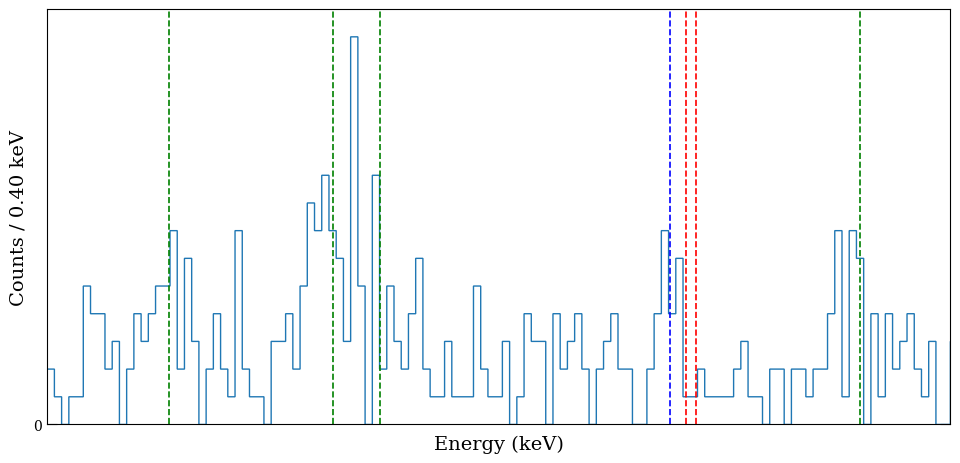

In [116]:

plt.figure(figsize=(10,5))
ax = plt.gca()


dx_major = 500
dx_minor = 100

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
#ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=7)

# Bin width
db =0.4
bins_common = np.arange(0,3000+db,db)


c, bc, _ = plt.hist(E_tot, bins = bins_common, 
             weights = Ntot, 
             histtype='step',
            )


db_plot = (bc[1]-bc[0]) 


plt.xlabel('Energy (keV)')
plt.ylabel(rf'Counts / {db_plot:.2f} keV')
#plt.yscale('log')
#plt.grid(alpha=0.15)
#ax.grid(which='major', linestyle='-', alpha=0.15)
#ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
#plt.legend(fontsize=15)
plt.vlines(756.73, 0, 15, color = 'green', ls = '--') # Ac 228
plt.vlines(765.8, 0, 15, color = 'green', ls = '--') # 95Nb
plt.vlines(768.4, 0, 15, color = 'green', ls = '--') #214Bi

plt.vlines(784.5, 0, 15, color = 'blue', ls = '--') #212Bi

plt.vlines(785.37, 0, 15, color = 'red', ls = '--') #212Bi

plt.vlines(785.9, 0, 15, color = 'red', ls = '--')  #214Pb

plt.vlines(795, 0, 15, color = 'green', ls = '--')
plt.xlim(750, 800)
plt.ylim(0,15)
plt.savefig("spectrum_50_days.png")
plt.show()


# Background

# PYMC

In [117]:
BACKGROUND_PEAKS = {
    "95Zr": {"E": 756.73, "N": 6.5},
    "214Bi": {"E": 768.4, "N": 5.11},
    "95Nb": {"E": 765.8, "N": 18},
    #"65Zr" : {"E": 770.62, "N" : 0},
    #"214Pb+212Bi": {"E": 785.95, "N": 3.33},
    #"228Ac-supp" :  {"E": 781.9, "N": 3.33},
    '???': {"E": 784.5, "N" : 0},
    "228Ac": {"E": 794.947, "N": 3.55},
}

In [118]:
roi_mask = (
    (E_tot > SIGNAL["roi"][0]) &
    (E_tot < SIGNAL["roi"][1])
)

E_roi = E_tot[roi_mask]
counts_roi = Ntot[roi_mask]

In [119]:


def gaussian(x, mu, sigma):
    return (1.0 / (pt.sqrt(2.0 * pt.pi) * sigma)) * pt.exp(
        -0.5 * ((x - mu) / sigma) ** 2
    )

with pm.Model() as model:

    # ========================================================
    # BACKGROUND PEAKS (tutti dentro il modello)
    # ========================================================
    A_bg = []
    mu_bg = []

    for peak_name in BACKGROUND_PEAKS:

        fit = BACKGROUND_PEAKS[peak_name]

        A = pm.HalfNormal(f"A_{peak_name}", sigma=1e4)

        mu = pm.Normal(
            f"mu_{peak_name}",
            mu=fit["E"],
            sigma=0.6
        )

        A_bg.append(A)
        mu_bg.append(mu)

    A_bg = pt.stack(A_bg)
    mu_bg = pt.stack(mu_bg)

    # ========================================================
    # SIGNAL
    # ========================================================
    A_signal = pm.HalfNormal("A_signal", sigma=1e4)

    mu_signal = SIGNAL["mu"]
    sigma_common = sigma_fun(mu_signal)

    # ========================================================
    # FLAT BACKGROUND
    # ========================================================
    Q = pm.Exponential("Q", lam=1/np.median(counts_roi)) *  BIN_WIDTH

    # ========================================================
    # MODEL BUILD (QUI è tutto il fit)
    # ========================================================

    # reshape E asse per broadcasting
    E = E_roi[None, :]   # (1, n_bins)

    # background Gaussians: (n_peaks, n_bins)
    bg_pdf = gaussian(E, mu_bg[:, None], sigma_common) * BIN_WIDTH

    # signal Gaussian: (n_bins,)
    sig_pdf = gaussian(E_roi, mu_signal, sigma_common) * BIN_WIDTH

    lambda_E = (
        Q
        + pt.sum(A_bg[:, None] * bg_pdf, axis=0)
        + A_signal * sig_pdf
    )

    lambda_E = pt.clip(lambda_E, 1e-9, np.inf)

    # ========================================================
    # LIKELIHOOD
    # ========================================================
    pm.Poisson("counts_obs", mu=lambda_E, observed=counts_roi)

    trace = pm.sample(
        draws=SAMPLING_CONFIG["draws"],
        tune=SAMPLING_CONFIG["tune"],
        chains=SAMPLING_CONFIG["chains"],
        cores=min(4, multiprocessing.cpu_count()),
        target_accept=SAMPLING_CONFIG["target_accept"],
        init="jitter+adapt_diag",
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A_95Zr, mu_95Zr, A_214Bi, mu_214Bi, A_95Nb, mu_95Nb, A_???, mu_???, A_228Ac, mu_228Ac, A_signal, Q]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


In [120]:
# ============================================================
# SUMMARY
# ============================================================
summary = az.summary(trace, round_to=4)
print(summary)

              mean      sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
mu_95Zr   756.6743  0.3014  756.1358  757.2450     0.0030   0.0037  9884.5432   
mu_214Bi  768.2295  0.5376  767.2654  769.2527     0.0077   0.0049  4928.6954   
mu_95Nb   765.5253  0.2958  764.9618  766.0504     0.0042   0.0028  5040.4882   
mu_???    784.4762  0.3092  783.9270  785.0970     0.0034   0.0048  8658.4258   
mu_228Ac  794.5455  0.3498  793.9008  795.2068     0.0041   0.0049  7672.4363   
A_95Zr     21.9057  6.2782   10.4182   34.1084     0.0692   0.0797  7640.6033   
A_214Bi    20.6004  7.6406    6.9233   34.8540     0.0968   0.0792  5832.7605   
A_95Nb     40.6371  9.1413   22.8097   56.9872     0.1103   0.1018  6705.4968   
A_???      13.5934  5.3324    3.5879   23.6551     0.0636   0.0682  6139.7150   
A_228Ac    17.7503  6.1266    6.6597   29.3343     0.0655   0.0644  7896.6110   
A_signal    7.3210  4.5329    0.0076   15.1942     0.0539   0.0494  4735.6273   
Q           4.6716  0.3369  

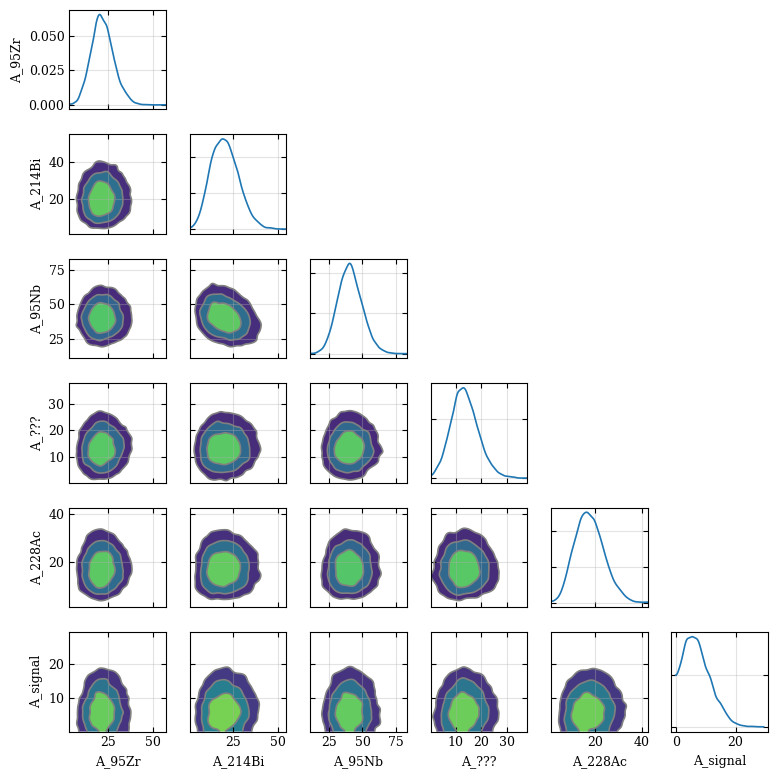

In [121]:

# ============================================================
# CORRELATION PLOTS
# ============================================================
A_vars = [v for v in trace.posterior.data_vars if v.startswith("A_")]

axes = az.plot_pair(
    trace,
    var_names=A_vars,
    kind="kde",
    marginals=True,
    figsize=(8, 8),
    textsize=9,
)

for ax in axes.flatten():
    ax.grid(alpha=0.35)

plt.tight_layout()
plt.show()


In [122]:


# ============================================================
# POSTERIOR OF SIGNAL
# ============================================================
signal_samples = trace.posterior["A_signal"].values.flatten()

N_signal_90 = np.percentile(signal_samples, 90)
N_signal_95 = np.percentile(signal_samples, 95)

print()
print("=" * 60)
print(f"90% upper limit on signal counts : {N_signal_90:.3f}")
print(f"95% upper limit on signal counts : {N_signal_95:.3f}")
print("=" * 60)


90% upper limit on signal counts : 13.588
95% upper limit on signal counts : 15.693


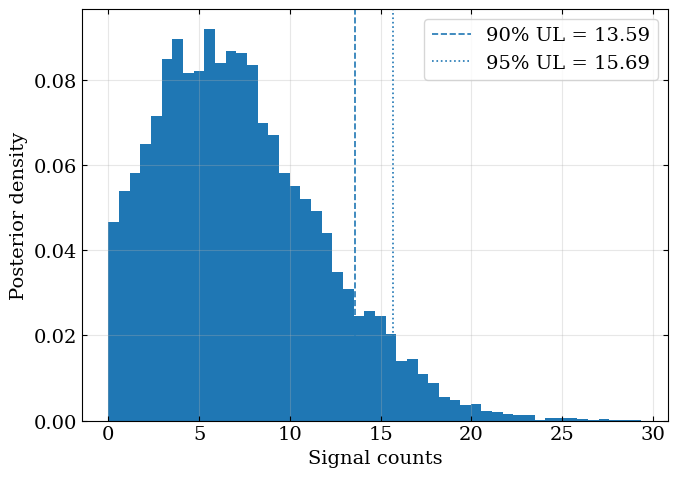

In [123]:
# ============================================================
# SIGNAL POSTERIOR PLOT
# ============================================================
plt.figure(figsize=(7, 5))

plt.hist(signal_samples, bins=50, density=True)

plt.axvline(
    N_signal_90,
    linestyle="--",
    label=f"90% UL = {N_signal_90:.2f}",
)

plt.axvline(
    N_signal_95,
    linestyle=":",
    label=f"95% UL = {N_signal_95:.2f}",
)

plt.xlabel("Signal counts")
plt.ylabel("Posterior density")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()



In [124]:
posterior_means = {name: trace.posterior[name].mean().values for name in trace.posterior.data_vars}

print("Ampiezze medie dei picchi:")
for name, val in posterior_means.items():
    print(f"{name}: {val:.2f}")

Ampiezze medie dei picchi:
mu_95Zr: 756.67
mu_214Bi: 768.23
mu_95Nb: 765.53
mu_???: 784.48
mu_228Ac: 794.55
A_95Zr: 21.91
A_214Bi: 20.60
A_95Nb: 40.64
A_???: 13.59
A_228Ac: 17.75
A_signal: 7.32
Q: 4.67


In [125]:
background_names = list(BACKGROUND_PEAKS.keys())

background_energies = np.array([
    BACKGROUND_PEAKS[name]["E"] for name in background_names
])

background_sigmas = sigma_fun(background_energies)


In [126]:
import numpy as np

# ============================================================
# POSTERIOR EXTRACTION
# ============================================================
idata = trace
posterior = idata.posterior

Q_s        = posterior["Q"].values.flatten()
A_signal_s = posterior["A_signal"].values.flatten()

A_bg_s = {
    name: posterior[f"A_{name}"].values.reshape(-1)
    for name in background_names
}

mu_bg_s = {
    name: posterior[f"mu_{name}"].values.reshape(-1)
    for name in background_names
}

# ============================================================
# GRID CONTINUA
# ============================================================
E_fine = np.linspace(E_roi.min(), E_roi.max(), 3000)

# ============================================================
# GAUSSIANA MODELLO
# ============================================================
def gaussian(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(
        -0.5 * ((x - mu) / sigma) ** 2
    )

sigma_common = sigma_fun(mu_signal)

# ============================================================
# COSTRUZIONE POSTERIOR PREDICTIONS (FULL)
# ============================================================
lambda_draws = []
lambda_bg_draws = []

for i in range(len(Q_s)):

    lam = Q_s[i] * np.ones_like(E_roi)
    lam_bg = Q_s[i] * np.ones_like(E_roi)

    for name in background_names:

        mu_i = mu_bg_s[name][i]

        bg_shape = gaussian(E_roi, mu_i, sigma_common)

        lam += A_bg_s[name][i] * bg_shape
        lam_bg += A_bg_s[name][i] * bg_shape

    sig_shape = gaussian(E_roi, mu_signal, sigma_common)
    lam += A_signal_s[i] * sig_shape

    lambda_draws.append(lam)
    lambda_bg_draws.append(lam_bg)

lambda_draws = np.array(lambda_draws)
lambda_bg_draws = np.array(lambda_bg_draws)

# ============================================================
# STATISTICHE POSTERIORI (BINNED)
# ============================================================
lambda_mean = lambda_draws.mean(axis=0)
lambda_std  = lambda_draws.std(axis=0)

lambda_low  = np.percentile(lambda_draws, 5, axis=0)
lambda_high = np.percentile(lambda_draws, 95, axis=0)

# ============================================================
# MEDIA PARAMETRI (PER CURVA LISCIA)
# ============================================================
posterior_means = {
    var: posterior[var].values.mean()
    for var in posterior.data_vars
}

# ============================================================
# CURVA LISCIA (MEAN MODEL)
# ============================================================
lambda_pred_bkg_fine = posterior_means["Q"] * np.ones_like(E_fine)

for name in background_names:

    mu = posterior_means[f"mu_{name}"]

    lambda_pred_bkg_fine += (
        posterior_means[f"A_{name}"]
        * gaussian(E_fine, mu, sigma_common)
    )

lambda_pred_fine = (
    lambda_pred_bkg_fine
    + posterior_means["A_signal"]
    * gaussian(E_fine, mu_signal, sigma_common)
)

# ============================================================
# FULL POSTERIOR SU GRIGLIA FINE (UNCERTAINTY BAND)
# ============================================================
lambda_fine_draws = []

for i in range(len(Q_s)):

    lam = Q_s[i] * np.ones_like(E_fine)

    for name in background_names:

        mu_i = mu_bg_s[name][i]

        lam += A_bg_s[name][i] * gaussian(E_fine, mu_i, sigma_common)

    lam += A_signal_s[i] * gaussian(E_fine, mu_signal, sigma_common)

    lambda_fine_draws.append(lam)

lambda_fine_draws = np.array(lambda_fine_draws)

lambda_fine_mean = lambda_fine_draws.mean(axis=0)
lambda_fine_low  = np.percentile(lambda_fine_draws, 5, axis=0)
lambda_fine_high = np.percentile(lambda_fine_draws, 95, axis=0)

# ============================================================
# SIGNAL LIMIT (90%)
# ============================================================
N_signal_90 = np.percentile(A_signal_s, 90)

print(N_signal_90)

lambda_limit_fine = lambda_pred_bkg_fine + N_signal_90 * gaussian(
    E_fine, mu_signal, sigma_common
)

# ============================================================
# RESIDUI NORMALIZZATI
# ============================================================
total_sigma = np.sqrt(lambda_mean + lambda_std**2)

residuals = (counts_roi - lambda_mean) / total_sigma

13.58834696397376


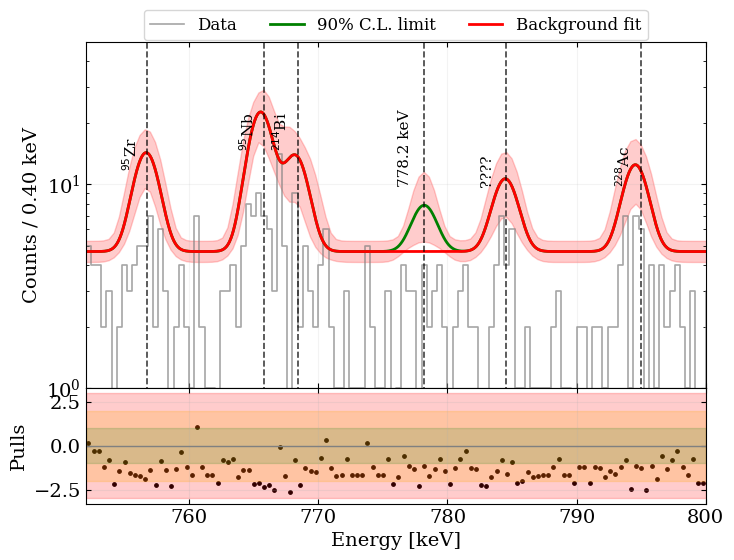

In [127]:


# ============================================================
# FIGURA
# ============================================================
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    figsize=(8, 6)
)

# ============================================================
# PLOT SUPERIORE
# ============================================================
ax1.step(
    E_roi,
    counts_roi,
    where='mid',
    color='grey',
    alpha=0.7,
    label='Data'
)

# modello totale
ax1.plot(
    E_fine,
    lambda_pred_fine,
    color='green',
    lw=2,
    label='90% C.L. limit'
)

# background
ax1.plot(
    E_fine,
    lambda_pred_bkg_fine,
    color='red',
    lw=2,
    label='Background fit'
)

# banda credibile background
ax1.fill_between(
    E_roi,
    lambda_low,
    lambda_high,
    color='red',
    alpha=0.2
)

ax1.set_yscale('log')
ax1.set_ylim(1, 50)
ax1.set_xlim(752, 800)

ax1.set_ylabel(
    f"Counts / {E_roi[1]-E_roi[0]:.2f} keV"
)


add_peak(ax1, 778.2, r"778.2 keV", 10)
add_peak(ax1, 756.73, r"$^{95}$Zr", 12)
add_peak(ax1, 765.8, r"$^{95}$Nb", 15)
add_peak(ax1, 768.4, r"$^{214}$Bi", 15)
add_peak(ax1, 784.5, r"????", 10)
add_peak(ax1, 794.947, r"$^{228}$Ac", 10)
#add_peak(ax1, 781.9, r"$^{228}$Ac", 10)
#add_peak(ax1, 770.62, r"$^{65}$Zr", 10)




ax1.grid(alpha=0.15)

ax1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    fontsize=12
)

# ============================================================
# RESIDUI
# ============================================================
ax2.scatter(
    E_roi,
    residuals,
    s=6,
    color='black'
)

ax2.axhspan(
    -3,
    3,
    color='red',
    alpha=0.20
)

ax2.axhspan(
    -2,
    2,
    color='orange',
    alpha=0.20
)

ax2.axhspan(
    -1,
    1,
    color='green',
    alpha=0.15
)

ax2.axhline(
    0,
    color='gray',
    lw=1
)

ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Pulls")

ax2.grid(alpha=0.2)

# ============================================================
# LAYOUT
# ============================================================
plt.subplots_adjust(hspace=0)

plt.show()

# Half life

In [128]:
# Dati campione
m_sample = 551.3        # massa ZrO2 in grammi
Mr_sample = 123.22      # massa molare ZrO2 [g/mol]
N_A = 6.022e23          # numero di Avogadro
eff_96Zr = 0.024131    # efficienza di rivelazione
i_a_96Zr = 0.0280     # abbondanza isotopica
t_live =    t_tot/(60*60*24*365)             # 90 giorni in anni


# Numero di nuclei 96Zr nel campione
N_nuclei = (m_sample * i_a_96Zr / Mr_sample) * N_A


In [129]:
# Posterior del numero di eventi segnale
signal_samples = trace.posterior['A_signal'].values.flatten()
signal_samples

array([10.72991   ,  6.37913883,  8.0005432 , ..., 12.73085443,
        5.12997117,  5.4829141 ], shape=(8000,))

In [130]:
N_signal_90

np.float64(13.58834696397376)

In [131]:

percentile = 90

T_half_limit = (np.log(2) * N_nuclei * eff_96Zr * t_live) / N_signal_90
print(f"T1/2 > {T_half_limit:.2e} yrs at {percentile}%")

T1/2 > 2.78e+19 yrs at 90%
